In [38]:
# standard
import time
import logging
import warnings
from datetime import date, datetime, timedelta
warnings.filterwarnings("ignore", category=FutureWarning)

# core data 
import numpy as np
import pandas as pd
import requests

# statistics econometrics
from scipy import stats
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

# machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize


from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
import tigramite.plotting as tp


# finance
import talib as ta

# network analysis
import networkx as nx

# visualization
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.patches as mpatches
import seaborn as sns


In [23]:
# get eth data 
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
SYMBOL   = "ETHUSDT"
INTERVAL = "1h"         
YEARS    = 3
DOLLAR_BAR_THRESHOLD = 500_000_000

def fetch_ohlcv(symbol: str, interval: str, years: int) -> pd.DataFrame:
    url        = "https://api.binance.com/api/v1/klines"
    start_time = datetime.now() - timedelta(days=365 * years)
    end_time   = datetime.now()
    all_data   = []
    chunk_map  = {"1m": 1, "1h": 40, "1d": 90}
    chunk_days = chunk_map.get(interval, 40)
    while start_time < end_time:
        params = {
            "symbol":    symbol,
            "interval":  interval,
            "startTime": int(start_time.timestamp() * 1000),
            "endTime":   int((start_time + timedelta(days=chunk_days)).timestamp() * 1000),
            "limit":     1000,
        }
        r = requests.get(url, params=params)
        if r.status_code != 200:
            logging.error(f"request failed: {r.status_code}")
            break
        data = r.json()
        if not data:
            break
        all_data.extend(data)
        start_time = pd.to_datetime(data[-1][0], unit="ms") + timedelta(milliseconds=1)
        logging.info(f"fetched up to {start_time}")
        time.sleep(0.25)
    cols = ["timestamp","open","high","low","close","volume",
            "close_time","quote_volume","trades",
            "taker_base","taker_quote","ignore"]
    df = pd.DataFrame(all_data, columns=cols)
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df.set_index("timestamp", inplace=True)
    for col in ["open","high","low","close","volume",
                "quote_volume","trades","taker_base","taker_quote"]:
        df[col] = df[col].astype(float)
    df["dollar_volume"] = df["close"] * df["volume"]
    return df[["open","high","low","close","volume","dollar_volume",
               "quote_volume","trades","taker_base","taker_quote"]]

def build_dollar_bars(df: pd.DataFrame, threshold: float) -> pd.DataFrame:
    bars      = []
    cum_dv    = 0.0
    o         = None
    h         = -np.inf
    l         = np.inf
    vol       = 0.0
    qvol      = 0.0
    trades    = 0.0
    t_base    = 0.0
    t_quote   = 0.0
    start_idx = None
    for ts, row in df.iterrows():
        if o is None:
            o         = row["open"]
            start_idx = ts
        h       = max(h, row["high"])
        l       = min(l, row["low"])
        vol    += row["volume"]
        cum_dv += row["dollar_volume"]
        qvol   += row["quote_volume"]
        trades += row["trades"]
        t_base += row["taker_base"]
        t_quote+= row["taker_quote"]
        if cum_dv >= threshold:
            bars.append({
                "timestamp":    start_idx,
                "open":         o,
                "high":         h,
                "low":          l,
                "close":        row["close"],
                "volume":       vol,
                "dollar_volume": cum_dv,
                "quote_volume": qvol,
                "trades":       trades,
                "taker_base":   t_base,
                "taker_quote":  t_quote,
            })
            o, h, l, vol, cum_dv = None, -np.inf, np.inf, 0.0, 0.0
            qvol, trades, t_base, t_quote = 0.0, 0.0, 0.0, 0.0
    bar_df = pd.DataFrame(bars).set_index("timestamp")
    logging.info(f"dollar bars created: {len(bar_df)} bars (threshold=${threshold:,.0f})")
    return bar_df

if __name__ == "__main__":
    raw = fetch_ohlcv(SYMBOL, INTERVAL, YEARS)
    raw.to_csv("eth_hourly2.csv")
    logging.info(f"hourly rows: {len(raw)}")
    dollar_bars = build_dollar_bars(raw, DOLLAR_BAR_THRESHOLD)
    dollar_bars.to_csv("eth_dollar_bars2.csv")
    print(dollar_bars.tail())
    print(f"\ntotal dollar bars: {len(dollar_bars)}")

2026-04-11 10:58:33,693 - INFO - fetched up to 2023-05-22 08:00:00.001000
2026-04-11 10:58:35,348 - INFO - fetched up to 2023-07-01 08:00:00.001000
2026-04-11 10:58:36,623 - INFO - fetched up to 2023-08-10 08:00:00.001000
2026-04-11 10:58:37,941 - INFO - fetched up to 2023-09-19 08:00:00.001000
2026-04-11 10:58:39,413 - INFO - fetched up to 2023-10-29 08:00:00.001000
2026-04-11 10:58:40,702 - INFO - fetched up to 2023-12-08 08:00:00.001000
2026-04-11 10:58:42,162 - INFO - fetched up to 2024-01-17 08:00:00.001000
2026-04-11 10:58:43,456 - INFO - fetched up to 2024-02-26 08:00:00.001000
2026-04-11 10:58:44,762 - INFO - fetched up to 2024-04-06 08:00:00.001000
2026-04-11 10:58:46,582 - INFO - fetched up to 2024-05-16 08:00:00.001000
2026-04-11 10:58:47,909 - INFO - fetched up to 2024-06-25 08:00:00.001000
2026-04-11 10:58:49,197 - INFO - fetched up to 2024-08-04 08:00:00.001000
2026-04-11 10:58:50,712 - INFO - fetched up to 2024-09-13 08:00:00.001000
2026-04-11 10:58:51,941 - INFO - fetch

                        open     high      low    close       volume  \
timestamp                                                              
2026-04-07 20:00:00  2113.39  2273.87  2110.68  2236.08  247137.4275   
2026-04-08 01:00:00  2236.09  2270.55  2186.61  2195.22  262377.5019   
2026-04-08 15:00:00  2195.23  2239.50  2158.19  2165.22  230252.4110   
2026-04-09 14:00:00  2165.23  2246.00  2157.31  2185.86  229341.6139   
2026-04-10 09:00:00  2185.85  2257.99  2185.83  2240.97  224981.5456   

                     dollar_volume  quote_volume     trades   taker_base  \
timestamp                                                                  
2026-04-07 20:00:00   5.472036e+08  5.444305e+08  2128156.0  130737.9239   
2026-04-08 01:00:00   5.860494e+08  5.875891e+08  2421197.0  123220.5126   
2026-04-08 15:00:00   5.053900e+08  5.052311e+08  3117121.0  107530.2278   
2026-04-09 14:00:00   5.050492e+08  5.048280e+08  3092921.0  112248.6617   
2026-04-10 09:00:00   5.024519e+08  5.0

In [75]:
# eda to get an overview
df = pd.read_csv("eth_dollar_bars2.csv", parse_dates=True, index_col=0)
df["return"] = df["close"].pct_change() * 100

# bars per year (dynamic, not hardcoded)
total_years = (df.index[-1] - df.index[0]).days / 365
bars_per_year = len(df) / total_years

mean_return = df["return"].mean()
median_return = df["return"].median()
volatility = df["return"].std()
skewness = df["return"].skew()
kurtosis = df["return"].kurt()

bar_sharpe    = mean_return / volatility
annual_sharpe = bar_sharpe * np.sqrt(bars_per_year)  # correct annualization

var_95 = df["return"].quantile(0.05)
var_99 = df["return"].quantile(0.01)

print(f"bars total:     {len(df)}")
print(f"bars per year:  {bars_per_year:.0f}")
print(f"mean return:    {mean_return:.2f}%")
print(f"median return:  {median_return:.2f}%")
print(f"volatility:     {volatility:.2f}%")
print(f"skewness:       {skewness:.2f}")
print(f"kurtosis:       {kurtosis:.2f}")
print(f"bar sharpe:     {bar_sharpe:.2f}")
print(f"annual sharpe:  {annual_sharpe:.2f}")
print(f"q1 (25%):       {df['return'].quantile(0.25):.2f}%")
print(f"q3 (75%):       {df['return'].quantile(0.75):.2f}%")
print(f"var 95%:        {var_95:.2f}%")
print(f"var 99%:        {var_99:.2f}%")

bars total:     2431
bars per year:  811
mean return:    0.03%
median return:  0.06%
volatility:     2.22%
skewness:       -0.02
kurtosis:       1.32
bar sharpe:     0.01
annual sharpe:  0.40
q1 (25%):       -1.36%
q3 (75%):       1.41%
var 95%:        -3.69%
var 99%:        -5.45%


durbin-watson:  1.96  (2.0 = no autocorr, <2 = positive)
      lb_stat  lb_pvalue
10   9.455085   0.489526
20  14.797211   0.787891


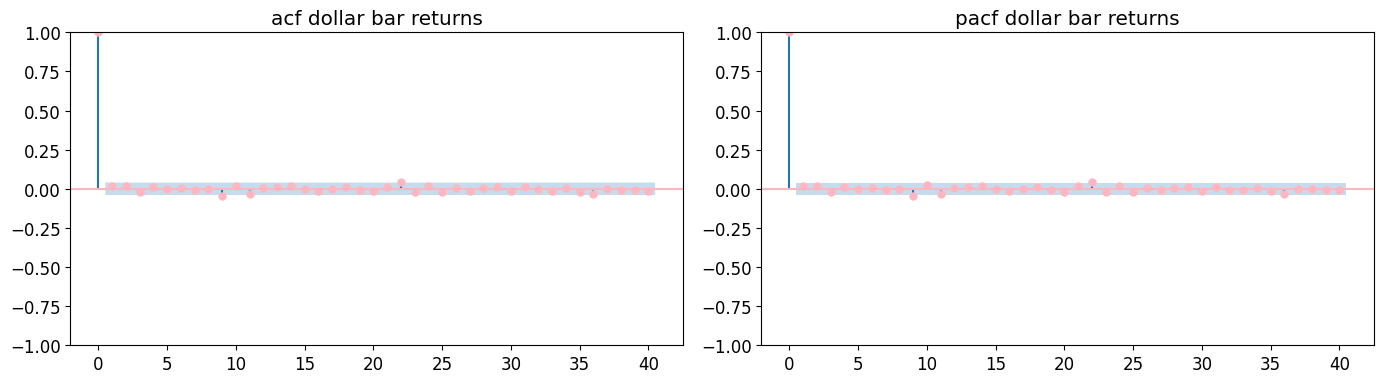

In [76]:
# testing for random walk
returns = df["return"].dropna()

# serial autocorrelation (de prado's primary motivation for dollar bars)
dw = durbin_watson(returns)
lb = acorr_ljungbox(returns, lags=[10, 20], return_df=True)

print(f"durbin-watson:  {dw:.2f}  (2.0 = no autocorr, <2 = positive)")
print(lb.to_string())

# also: plot acf/pacf
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sm.graphics.tsa.plot_acf(returns, lags=40, ax=axes[0], color='#FFB6C1')
sm.graphics.tsa.plot_pacf(returns, lags=40, ax=axes[1], color='#FFB6C1')
axes[0].set_title("acf dollar bar returns")
axes[1].set_title("pacf dollar bar returns")
plt.tight_layout()
plt.savefig("results/autocorrelation_dollar_bars.png", dpi=300, bbox_inches='tight')
plt.show()

In [77]:
# key insights:

# lag 0 spike correlation(today, today) = 1.0. always
# blue band: 95% confidence interval: roughly ±2 / sqrt(n)
# any bar inside = statistically indistinguishable from zero = no real pattern

# acf, autocorrelation function
# question: does today's return relate to the return N bars ago?
# lag 3 acf includes indirect influence from lags 1 and 2 as well

# pacf, partial autocorrelation function
# does today relate to N bars ago, after removing all the middlemen?


# durbin-watson: 1.9529, scale runs 0 to 4
# 2.0 = no autocorrelation (each bar is independent of the last)
# < 2 = positive autocorrelation (good bars tend to follow good bars)
# > 2 = negative autocorrelation (good bars tend to flip to bad bars)


# ljung-box test
# across all lags up to N, is there *any* hidden autocorrelation hiding together?
# bundles them into one p-value
# p > 0.05 = no significant autocorrelation found (you fail to reject H0)
# p < 0.05 = something is there, worth investigating

#-> no memory, no exploitable linear structure in the return series itself

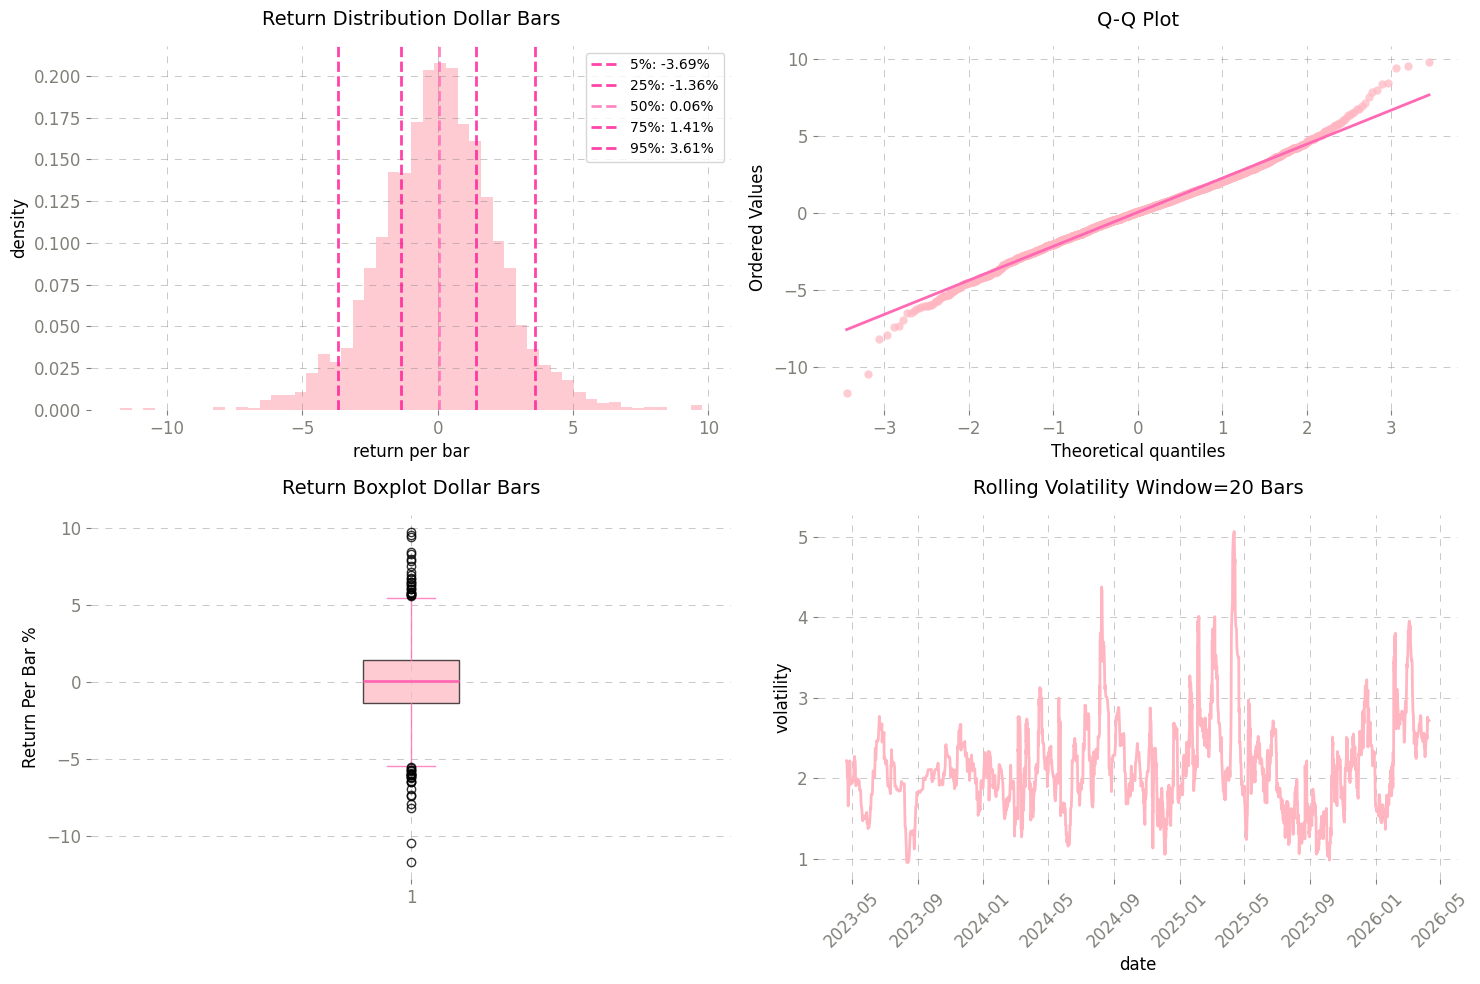

In [78]:
# rolling window: ~20 bars ≈ one trading day at this threshold
rolling_window = 20

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12

axes[0,0].hist(df["return"].dropna(), bins=50, alpha=0.7, density=True,
               color='#FFB6C1', edgecolor='none')
for i, q_val in enumerate([0.05, 0.25, 0.5, 0.75, 0.95]):
    color = '#FF69B4' if i == 2 else '#FF1493'
    axes[0,0].axvline(df["return"].quantile(q_val),
                      color=color, linestyle='--', alpha=0.8, linewidth=2,
                      label=f'{q_val*100:.0f}%: {df["return"].quantile(q_val):.2f}%')
axes[0,0].set_title("Return Distribution Dollar Bars", fontsize=14, pad=15)
axes[0,0].legend(fontsize=10)
axes[0,0].set_xlabel("return per bar", fontsize=12)
axes[0,0].set_ylabel("density", fontsize=12)

stats.probplot(df["return"].dropna(), dist="norm", plot=axes[0,1])
axes[0,1].get_lines()[0].set_markerfacecolor('#FFB6C1')
axes[0,1].get_lines()[0].set_markeredgecolor('none')
axes[0,1].get_lines()[0].set_alpha(0.7)
axes[0,1].get_lines()[1].set_color('#FF69B4')
axes[0,1].get_lines()[1].set_linewidth(2)
axes[0,1].set_title("Q-Q Plot", fontsize=14, pad=15)

bp = axes[1,0].boxplot(df["return"].dropna(), patch_artist=True)
bp['boxes'][0].set_facecolor('#FFB6C1')
bp['boxes'][0].set_alpha(0.7)
bp['medians'][0].set_color('#FF69B4')
bp['medians'][0].set_linewidth(2)
for element in ['whiskers', 'fliers', 'caps']:
    for item in bp[element]:
        item.set_color('#FF69B4')
        item.set_alpha(0.8)
axes[1,0].set_ylabel("Return Per Bar %", fontsize=12)
axes[1,0].set_title("Return Boxplot Dollar Bars", fontsize=14, pad=15)

df["rolling_vol"] = df["return"].rolling(window=rolling_window).std()
axes[1,1].plot(df.index, df["rolling_vol"], color='#FFB6C1', linewidth=2)
axes[1,1].set_title(f"Rolling Volatility Window={rolling_window} Bars", fontsize=14, pad=15)
axes[1,1].set_ylabel("volatility", fontsize=12)
axes[1,1].set_xlabel("date", fontsize=12)

for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.grid(True, color="gray", linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)
    [t.set_color('#808079') for t in ax.yaxis.get_ticklabels()]
    [t.set_color('#808079') for t in ax.xaxis.get_ticklabels()]
    ax.tick_params(axis="x", colors="#808079")
    ax.tick_params(axis="y", colors="#808079")

axes[1,1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("results/return_distribution_dollar_bars.png", dpi=300, bbox_inches='tight')
plt.show()


In [79]:
# histogram 
# shape looks roughly bell-curved, but tails extend to ±10% 
# kurtosis = 1.34 confirms this: leptokurtic (fatter tails than normal)

# q-q plot 
# bottom-left: more large negative returns than normal predicts
# top-right: more large positive returns than normal predicts
# var based on normal distribution will underestimate real tail risk

# boxplot
# box is tight and symmetric around zero
# whiskers reach to roughly ±5-6%
# outliers, fat tail events, some go to ±10-12%

# rolling volatility 
# volatility clusters, calm regimes: ~1.5%, stressed regimes: ~4-5%
# tspike around 2025-04 is notable (~5%)
# single global volatility number is misleading as a feature
# regime-aware features (e.g. vol-of-vol, rolling std ratio) will matter
# consider: triple barrier labeling use dynamic (rolling) vol thresholds


In [80]:
# generate features, using the insights of the eda
df['return'] = df['close'].pct_change() * 100

# volatility
df['volatility_7b'] = df['close'].rolling(window=7).std().shift(1)

# volume_change still varies even in dollar bars
df['volume_change'] = df['volume'].pct_change().replace([np.inf, -np.inf], np.nan).shift(1)

# vol regime
vol_rolling_quantiles = df['close'].rolling(window=7).std().rolling(30)
df['vol_regime'] = np.where(
    df['volatility_7b'] > vol_rolling_quantiles.quantile(0.75).shift(1), 2,
    np.where(df['volatility_7b'] < vol_rolling_quantiles.quantile(0.25).shift(1), 0, 1)
)

df['vol_regime_change'] = (df['vol_regime'] != df['vol_regime'].shift(1)).astype(int)
df['vol_momentum']      = df['volatility_7b'] / df['volatility_7b'].shift(1).rolling(14).mean() - 1
df['vol_expansion']     = (df['volatility_7b'] > df['volatility_7b'].shift(1) * 1.5).astype(int)
df['vol_persistence']   = (df['volatility_7b'] > df['volatility_7b'].shift(1)).astype(int)

# extreme moves
df['extreme_down'] = (df['return'] < df['return'].rolling(90).quantile(0.05).shift(1)).astype(int)
df['extreme_up']   = (df['return'] > df['return'].rolling(90).quantile(0.95).shift(1)).astype(int)

extreme_events      = (df['extreme_down'] | df['extreme_up']).astype(int)
df['extreme_streak'] = extreme_events.groupby(
    (extreme_events != extreme_events.shift()).cumsum()
).cumsum()

# drawdown 
# threshold -0.15: price-based, not bar-based
df['running_max']   = df['close'].rolling(30).max().shift(1)
df['drawdown']      = (df['close'] - df['running_max']) / df['running_max']
df['deep_drawdown'] = (df['drawdown'] < -0.15).astype(int)

# volume 
df['volume_zscore'] = ((df['volume'] - df['volume'].rolling(30).mean()) /
                        df['volume'].rolling(30).std()).shift(1)
df['volume_spike']  = (df['volume_zscore'] > 2).astype(int)

df['vwap']          = (df['volume'] * df['close']).rolling(20).sum() / df['volume'].rolling(20).sum()
df['vwap_distance'] = ((df['close'] - df['vwap'].shift(1)) / df['vwap'].shift(1))

# fat tails / var 
df['tail_risk_signal'] = ((df['volatility_7b'] > df['volatility_7b'].rolling(60).quantile(0.9).shift(1)) &
                           (df['volume_zscore'] > 1.5)).astype(int)

# capital flow
df["dollar_vol_z"] = ((df["dollar_volume"] - df["dollar_volume"].rolling(30).mean())
    / df["dollar_volume"].rolling(30).std()).shift(1)

# consecutive extreme moves: leading indicator for regime transitions
df["ret_raw"] = df["close"].pct_change(1).shift(1)
df["ret_5"]  = df["close"].pct_change(5).shift(1)

# 812 bars ≈ 1 year for dollar bars
bars_per_year = 812
df['var_breach_95'] = (df['return'].shift(1) < df['return'].rolling(bars_per_year).quantile(0.05).shift(1)).astype(int)
df['var_breach_99'] = (df['return'].shift(1) < df['return'].rolling(bars_per_year).quantile(0.01).shift(1)).astype(int)

df['position_size_factor'] = 1 / (df['volatility_7b'] / df['volatility_7b'].rolling(60).mean())
df['upside_momentum']      = (df['return'].shift(1) > df['return'].rolling(21).quantile(0.75).shift(1)).astype(int)

# talib 
def add_ta_indicators(df):
    for col in ['open','high','low','close','volume']:
        df[col] = df[col].astype('float64')

    df['open_lag1']   = df['open'].shift(1)
    df['high_lag1']   = df['high'].shift(1)
    df['low_lag1']    = df['low'].shift(1)
    df['close_lag1']  = df['close'].shift(1)
    df['volume_lag1'] = df['volume'].shift(1)

    df['atr_14'] = ta.ATR(df['high_lag1'], df['low_lag1'], df['close_lag1'], timeperiod=14)
    df['rsi']    = ta.RSI(df['close_lag1'], timeperiod=14)

    upper, middle, lower = ta.BBANDS(df['close_lag1'], timeperiod=20,
                                      nbdevup=2, nbdevdn=2, matype=0)
    df['bb_upper']    = upper
    df['bb_middle']   = middle
    df['bb_lower']    = lower
    df['bb_width']    = ((df['bb_upper'] - df['bb_lower']) / df['close_lag1']).fillna(0)
    df['bb_position'] = ((df['close_lag1'] - df['bb_lower']) /
                          (df['bb_upper'] - df['bb_lower'])).clip(0, 1)
    return df

df = add_ta_indicators(df)

df['atr_normalized']       = df['atr_14'] / df['close'].shift(1)
df['rsi_oversold_extreme']  = (df['rsi'] < 25).astype(int)
df['rsi_overbought_extreme'] = (df['rsi'] > 85).astype(int)

# market stress
df['market_stress'] = ((df['vol_regime'] == 2).astype(int) * 0.4 +
                        (df['volume_zscore'] > 2).astype(int) * 0.3 +
                        (df['extreme_streak'] > 2).astype(int) * 0.3)



# order flow features (taker = aggressive market orders)
df['taker_buy_vol']    = df['taker_quote']
df['taker_sell_vol']   = df['quote_volume'] - df['taker_quote']

# order flow imbalance
df['ofi']              = ((df['taker_buy_vol'] - df['taker_sell_vol']) /
                          (df['taker_buy_vol'] + df['taker_sell_vol'])).shift(1)

df['trades_change']    = df['trades'].pct_change().replace([np.inf, -np.inf], np.nan).shift(1)

# trade_intensity z-scoring against rolling window becomes stationary:
df['trade_intensity']  = (df['trades'] / df['dollar_volume']).shift(1)
df['trade_intensity_z'] = ((df['trade_intensity'] - df['trade_intensity'].rolling(30).mean()) /
                            df['trade_intensity'].rolling(30).std()).shift(1)



df.drop(columns=['atr_14', 'vwap', 'running_max', 'trade_intensity', 'trades'], inplace=True, errors='ignore')


In [81]:
# check if nans are clustered at start or scattered throughout
print("nan location check:")
warmup_cutoff = 70  # max of any rolling window 

for col in df.columns[df.isnull().any()]:
    total    = df[col].isnull().sum()
    in_start = df[col].iloc[:warmup_cutoff].isnull().sum()
    scattered = total - in_start
    flag = "  PROBLEM: scattered nans, ffill silently corrupts" if scattered > 0 else ""
    print(f"  {col:30s} total={total:3d}  start={in_start:3d}  scattered={scattered:3d}{flag}")

nan location check:
  return                         total=  1  start=  1  scattered=  0
  rolling_vol                    total= 20  start= 20  scattered=  0
  volatility_7b                  total=  7  start=  7  scattered=  0
  volume_change                  total=  2  start=  2  scattered=  0
  vol_momentum                   total= 21  start= 21  scattered=  0
  drawdown                       total= 30  start= 30  scattered=  0
  volume_zscore                  total= 30  start= 30  scattered=  0
  vwap_distance                  total= 20  start= 20  scattered=  0
  dollar_vol_z                   total= 30  start= 30  scattered=  0
  ret_raw                        total=  2  start=  2  scattered=  0
  ret_5                          total=  6  start=  6  scattered=  0
  position_size_factor           total= 66  start= 66  scattered=  0
  open_lag1                      total=  1  start=  1  scattered=  0
  high_lag1                      total=  1  start=  1  scattered=  0
  low_lag1    

In [82]:
# replace inf with nan first
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# check before filling
nan_report = df.isnull().sum()
nan_report = nan_report[nan_report > 0]
print("columns with nan:")
print(nan_report)

# only forward-fill, then drop remaining (warmup rows at the start)
df = df.ffill()
df.dropna(inplace=True)

print(f"remaining nulls: {df.isnull().sum().sum()}")
print(f"rows after cleanup: {len(df)}")

columns with nan:
return                   1
rolling_vol             20
volatility_7b            7
volume_change            2
vol_momentum            21
drawdown                30
volume_zscore           30
vwap_distance           20
dollar_vol_z            30
ret_raw                  2
ret_5                    6
position_size_factor    66
open_lag1                1
high_lag1                1
low_lag1                 1
close_lag1               1
volume_lag1              1
rsi                     15
bb_upper                20
bb_middle               20
bb_lower                20
bb_position             20
atr_normalized          15
ofi                      1
trades_change            2
trade_intensity_z       31
dtype: int64
remaining nulls: 0
rows after cleanup: 2365


In [83]:
#showing all the columns
pd.set_option('display.max_columns', None)
df.head(3)

,open,high,low,close,volume,dollar_volume,quote_volume,taker_base,taker_quote,return,rolling_vol,volatility_7b,volume_change,vol_regime,vol_regime_change,vol_momentum,vol_expansion,vol_persistence,extreme_down,extreme_up,extreme_streak,drawdown,deep_drawdown,volume_zscore,volume_spike,vwap_distance,tail_risk_signal,dollar_vol_z,ret_raw,ret_5,var_breach_95,var_breach_99,position_size_factor,upside_momentum,open_lag1,high_lag1,low_lag1,close_lag1,volume_lag1,rsi,bb_upper,bb_middle,bb_lower,bb_width,bb_position,atr_normalized,rsi_oversold_extreme,rsi_overbought_extreme,market_stress,taker_buy_vol,taker_sell_vol,ofi,trades_change,trade_intensity_z
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-05-23 10:00:00,1855.19,1860.61,1812.13,1826.13,272884.8757,5.023795e+08,5.025608e+08,127568.7328,2.350507e+08,-1.566947,1.508999,23.080888,-0.031178,0,0,-0.103106,0,1,0,0,0,-0.077475,0,-0.547514,0,0.002614,0,-0.614155,0.021361,0.028239,0,0,1.546408,1,1816.40,1872.50,1813.33,1855.20,274650.4345,52.927168,1881.388564,1822.5470,1763.705436,0.063434,0.777465,0.028704,0,0,0.0,2.350507e+08,2.675101e+08,0.185210,-0.242206,1.478478
2023-05-24 06:00:00,1826.13,1826.45,1777.60,1800.41,280900.7479,5.057047e+08,5.056273e+08,132338.7289,2.381304e+08,-1.408443,1.531131,23.097726,-0.006428,0,0,-0.093599,0,1,0,0,0,-0.090468,0,-0.663645,0,-0.010379,0,-0.878472,-0.015669,0.026816,0,0,1.503522,0,1855.19,1860.61,1812.13,1826.13,272884.8757,48.432308,1874.989854,1820.3335,1765.677146,0.059860,0.553027,0.028974,0,0,0.0,2.381304e+08,2.674969e+08,-0.064588,0.006130,-0.684587
2023-05-24 22:00:00,1800.42,1812.76,1761.41,1797.11,285461.7493,5.106357e+08,5.108251e+08,134885.5091,2.413564e+08,-0.183292,1.497993,23.450490,0.029375,1,1,-0.087125,0,1,0,0,0,-0.092135,0,-0.115636,0,-0.010689,0,-0.726349,-0.014084,-0.008284,0,0,1.445788,0,1826.13,1826.45,1777.60,1800.41,280900.7479,44.806621,1870.150714,1817.5180,1764.885286,0.058467,0.337478,0.029227,0,0,0.0,2.413564e+08,2.694687e+08,-0.058079,0.035070,-0.539616


In [84]:
df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'dollar_volume',
       'quote_volume', 'taker_base', 'taker_quote', 'return', 'rolling_vol',
       'volatility_7b', 'volume_change', 'vol_regime', 'vol_regime_change',
       'vol_momentum', 'vol_expansion', 'vol_persistence', 'extreme_down',
       'extreme_up', 'extreme_streak', 'drawdown', 'deep_drawdown',
       'volume_zscore', 'volume_spike', 'vwap_distance', 'tail_risk_signal',
       'dollar_vol_z', 'ret_raw', 'ret_5', 'var_breach_95', 'var_breach_99',
       'position_size_factor', 'upside_momentum', 'open_lag1', 'high_lag1',
       'low_lag1', 'close_lag1', 'volume_lag1', 'rsi', 'bb_upper', 'bb_middle',
       'bb_lower', 'bb_width', 'bb_position', 'atr_normalized',
       'rsi_oversold_extreme', 'rsi_overbought_extreme', 'market_stress',
       'taker_buy_vol', 'taker_sell_vol', 'ofi', 'trades_change',
       'trade_intensity_z'],
      dtype='object')

near-duplicate feature pairs (corr > 0.85):

    feature_1      feature_2  correlation
  taker_quote  taker_buy_vol     1.000000
dollar_volume   quote_volume     0.999390
       volume     taker_base     0.976208
 quote_volume taker_sell_vol     0.903386
dollar_volume taker_sell_vol     0.900176
dollar_volume    taker_quote     0.898521
dollar_volume  taker_buy_vol     0.898521
 quote_volume    taker_quote     0.896318
 quote_volume  taker_buy_vol     0.896318
          rsi    bb_position     0.885755
vwap_distance            rsi     0.861066
vwap_distance    bb_position     0.850079

feature clusters (redundant groups):

cluster 1: ['volume', 'taker_base']
cluster 2: ['dollar_volume', 'quote_volume', 'taker_quote', 'taker_buy_vol', 'taker_sell_vol']
cluster 3: ['vwap_distance', 'rsi', 'bb_position']


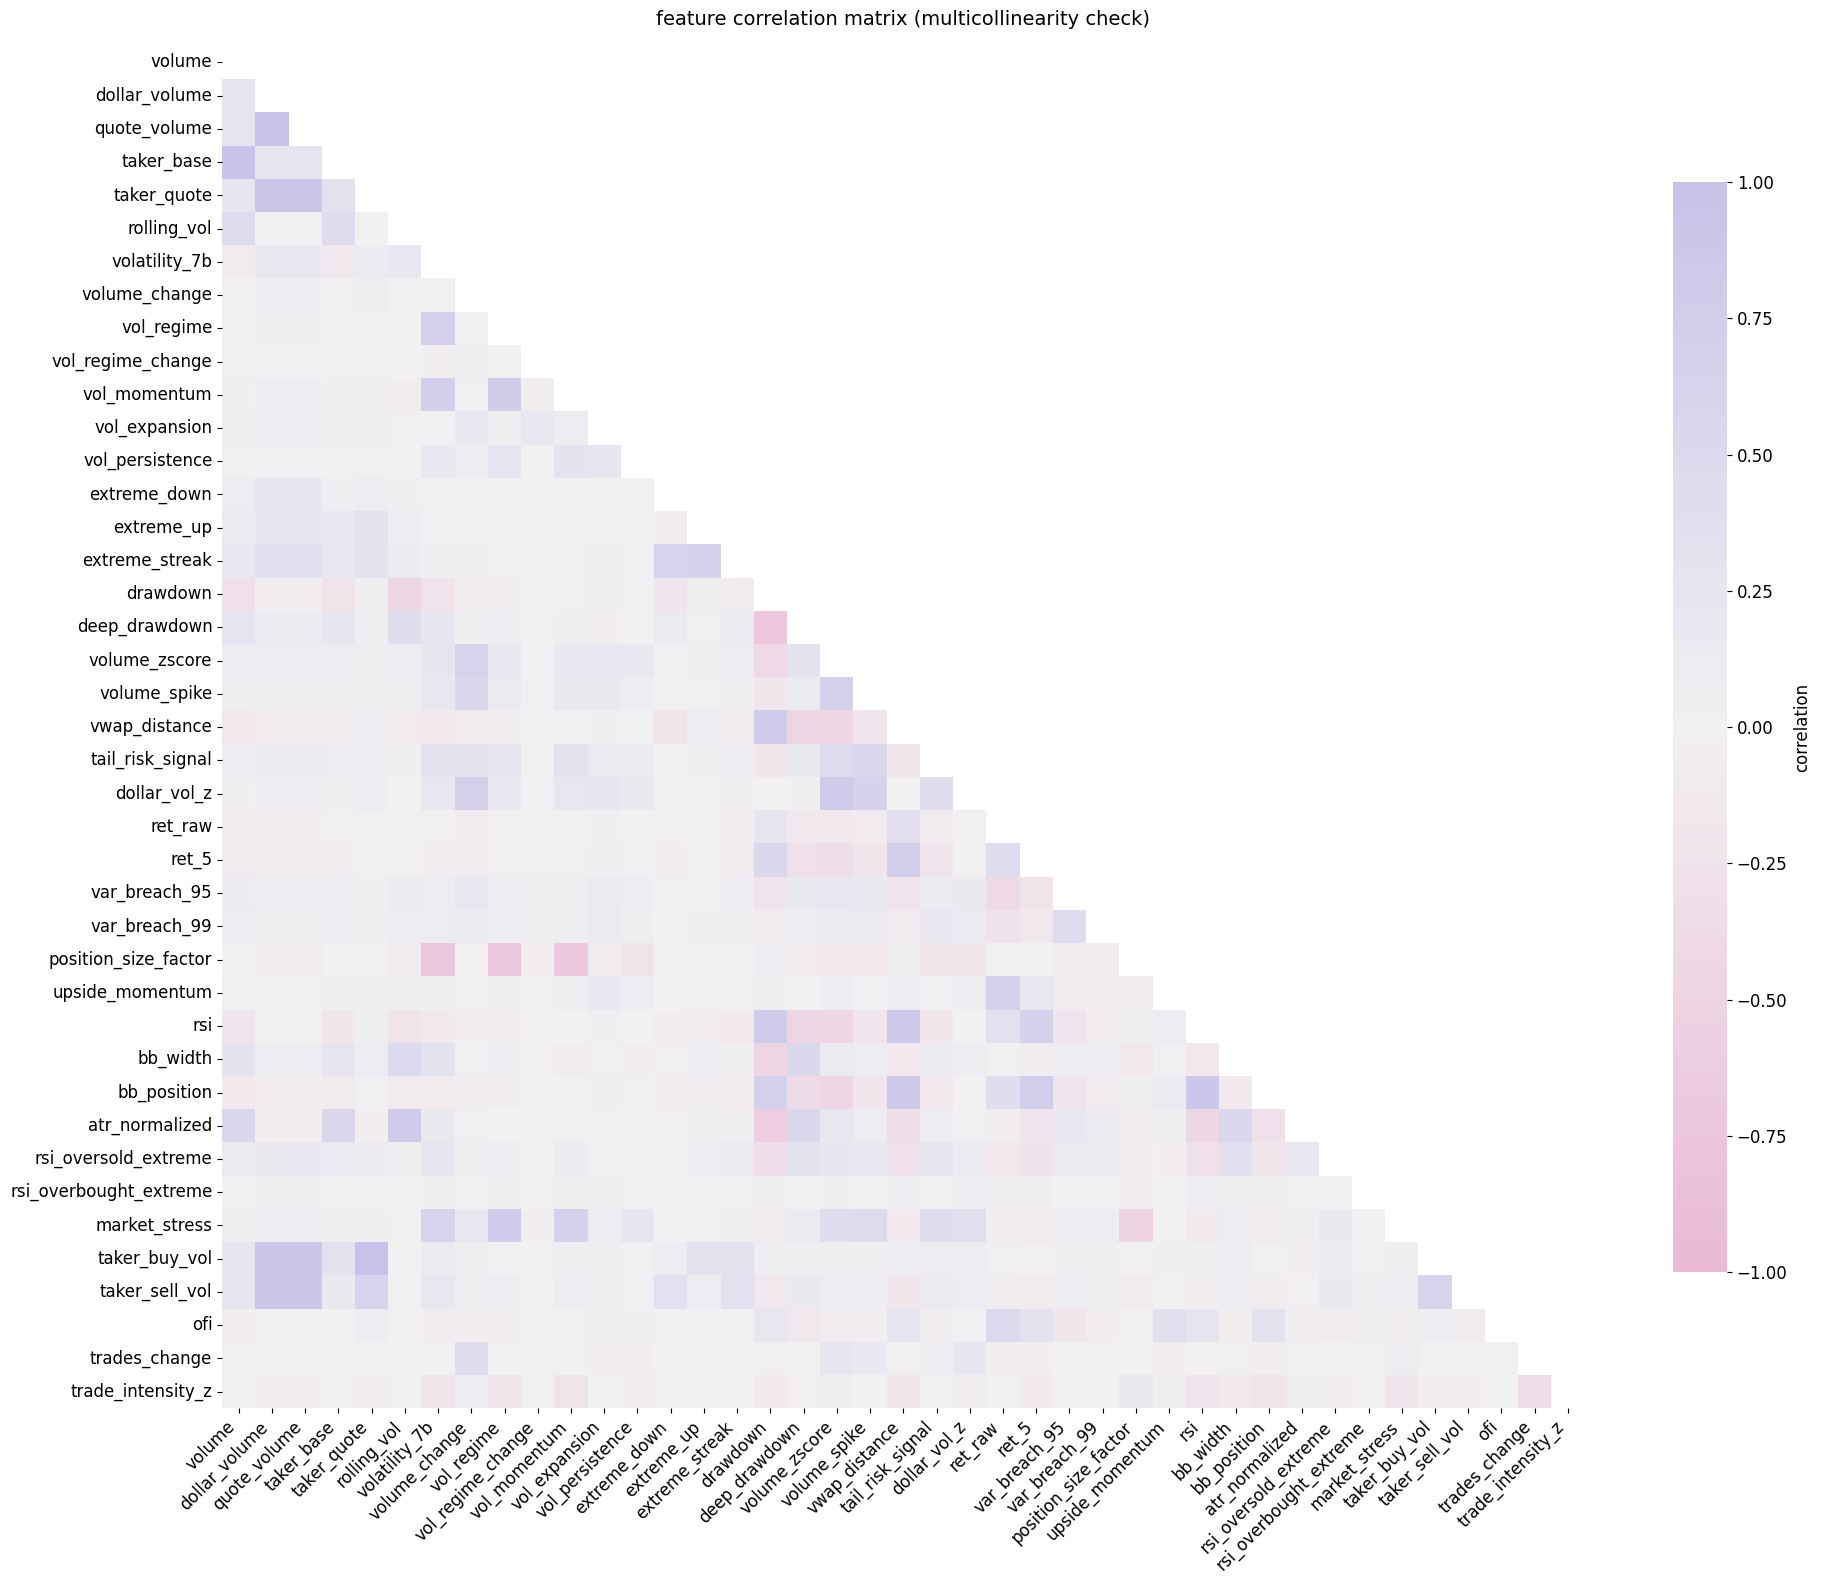

In [86]:
# multicollinearity hygiene only, not feature selection
# feature importance comes later from mdi/mda on the trained model

feature_cols = [col for col in df.columns if col not in
                ['ticker', 'open', 'high', 'low', 'close', 'return',
                 'open_lag1', 'high_lag1', 'low_lag1', 'close_lag1',
                 'volume_lag1', 'bb_upper', 'bb_middle', 'bb_lower']]

correlation_matrix = df[feature_cols].corr()

def find_high_correlations(corr_matrix, threshold=0.85):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            val = corr_matrix.iloc[i, j]
            if abs(val) > threshold:
                pairs.append({'feature_1': cols[i], 'feature_2': cols[j], 'correlation': val})
    return pd.DataFrame(pairs).sort_values('correlation', key=abs, ascending=False)

def build_feature_clusters(corr_matrix, threshold=0.85):
    processed, clusters = set(), []
    for feat in corr_matrix.columns:
        if feat in processed:
            continue
        cluster = [feat]
        for other in corr_matrix.columns:
            if other != feat and other not in processed:
                if abs(corr_matrix.loc[feat, other]) > threshold:
                    cluster.append(other)
        if len(cluster) > 1:
            processed.update(cluster)
            clusters.append(cluster)
    return clusters

high_corr_df   = find_high_correlations(correlation_matrix, threshold=0.85)
feature_clusters = build_feature_clusters(correlation_matrix, threshold=0.85)

print("near-duplicate feature pairs (corr > 0.85):\n")
print(high_corr_df.to_string(index=False))
print("\nfeature clusters (redundant groups):\n")
for i, c in enumerate(feature_clusters):
    print(f"cluster {i+1}: {c}")

# style
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size']   = 12

pastel_cmap = sns.diverging_palette(
    330,
    270,
    s=60,
    l=80,
    center="light",
    as_cmap=True
)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(20, 16))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap=pastel_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.0,
    cbar_kws={'label': 'correlation', 'shrink': 0.8}
)
plt.title('feature correlation matrix (multicollinearity check)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("results/correlation.png", dpi=300, bbox_inches='tight')
plt.show()

In [87]:
# all three features (vwap_distance, rsi, bb_position) are retained
# high inter-feature correlation does not imply low predictive value
# final selection deferred to mdi/mda, importance scores post-training


In [88]:
# test all features for stationarity
# adf, augmented dickey-fuller, checks if a series has a unit root (= drifts systematically over time)
# p < 0.05: stationary 
# p >= 0.05: non-stationary, needs differencing 
# this is not feature selection: all stationary features proceed to training
# importance ranking happens post-training via mdi/mda

def adf_test(series: pd.Series, name: str) -> dict:
    clean = series.dropna()
    # skip binary/constant features, adf meaningless there
    if clean.nunique() <= 2 or clean.std() == 0:
        return {'feature': name, 'adf_stat': None, 'p_value': None,
                'stationary': True, 'note': 'binary/constant - skipped'}
    result = adfuller(clean, autolag='AIC')
    return {
        'feature':    name,
        'adf_stat':   round(result[0], 4),
        'p_value':    round(result[1], 4),
        'stationary': result[1] < 0.05,
        'note':       'ok' if result[1] < 0.05 else 'NON-STATIONARY',
    }

results = pd.DataFrame([adf_test(df[f], f) for f in feature_cols if f in df.columns])
results = results.sort_values('p_value', na_position='last')
print(results.to_string(index=False))
print("─" * 70)
print(f"stationary:     {results['stationary'].sum()} / {len(results)}")
print(f"non-stationary: {(~results['stationary']).sum()} / {len(results)}")

stationary_features = results[results['stationary']]['feature'].tolist()

               feature  adf_stat  p_value  stationary                      note
         vwap_distance  -10.2559   0.0000        True                        ok
                   ofi  -19.7533   0.0000        True                        ok
        taker_sell_vol  -11.3482   0.0000        True                        ok
         taker_buy_vol  -10.8872   0.0000        True                        ok
         market_stress  -18.3985   0.0000        True                        ok
           bb_position  -11.9691   0.0000        True                        ok
              bb_width   -8.8967   0.0000        True                        ok
                   rsi   -8.7372   0.0000        True                        ok
  position_size_factor  -13.9058   0.0000        True                        ok
                 ret_5   -8.5007   0.0000        True                        ok
               ret_raw  -47.5626   0.0000        True                        ok
          dollar_vol_z  -19.1262   0.000

In [89]:
# check if binary features are actually binary or just constant
# rough threshold: feature needs at least ~1% positive cases to be learnable
for f in stationary_features:
    n = df[f].nunique()
    if n <= 2:
        print(f"{f}: {df[f].value_counts().to_dict()}")

vol_regime_change: {0: 1689, 1: 676}
vol_expansion: {0: 2236, 1: 129}
vol_persistence: {0: 1186, 1: 1179}
extreme_down: {0: 2221, 1: 144}
extreme_up: {0: 2222, 1: 143}
deep_drawdown: {0: 2060, 1: 305}
volume_spike: {0: 2233, 1: 132}
tail_risk_signal: {0: 2301, 1: 64}
var_breach_95: {0: 2277, 1: 88}
var_breach_99: {0: 2347, 1: 18}
upside_momentum: {0: 1829, 1: 536}
rsi_oversold_extreme: {0: 2326, 1: 39}
rsi_overbought_extreme: {0: 2362, 1: 3}


In [90]:
rare_binary = ['rsi_overbought_extreme', 'var_breach_99',
               'rsi_oversold_extreme', ]#'tail_risk_signal'
stationary_features = [f for f in stationary_features if f not in rare_binary]
df.drop(columns=rare_binary, inplace=True, errors='ignore')

In [91]:
# checking columns, which ones to exclude for graph
print(df.dtypes)

open                    float64
high                    float64
low                     float64
close                   float64
volume                  float64
dollar_volume           float64
quote_volume            float64
taker_base              float64
taker_quote             float64
return                  float64
rolling_vol             float64
volatility_7b           float64
volume_change           float64
vol_regime                int64
vol_regime_change         int64
vol_momentum            float64
vol_expansion             int64
vol_persistence           int64
extreme_down              int64
extreme_up                int64
extreme_streak            int64
drawdown                float64
deep_drawdown             int64
volume_zscore           float64
volume_spike              int64
vwap_distance           float64
tail_risk_signal          int64
dollar_vol_z            float64
ret_raw                 float64
ret_5                   float64
var_breach_95             int64
position

In [92]:
# causal discovery requires continuous, non-derived features only
# binary and composite features violate fisherz assumptions

cd_exclude = [
    'vol_regime_change',
    'vol_expansion',
    'vol_persistence',
    'extreme_down',
    'extreme_up',
    'deep_drawdown',
    'volume_spike',
    'tail_risk_signal',
    'var_breach_95',
    'upside_momentum'
]

cd_features = [f for f in stationary_features if f not in cd_exclude]

node_names = cd_features  

data_cd    = df[cd_features].dropna()
data_array = data_cd.values.astype(np.float64)
print(f"observations: {data_array.shape[0]}, features: {data_array.shape[1]}")
print(f"cd_features: {cd_features}")


observations: 2365, features: 28
cd_features: ['vwap_distance', 'ofi', 'taker_sell_vol', 'taker_buy_vol', 'market_stress', 'bb_position', 'bb_width', 'rsi', 'position_size_factor', 'ret_5', 'ret_raw', 'dollar_vol_z', 'trades_change', 'trade_intensity_z', 'drawdown', 'extreme_streak', 'vol_momentum', 'vol_regime', 'volume_change', 'volatility_7b', 'taker_quote', 'quote_volume', 'dollar_volume', 'volume_zscore', 'rolling_vol', 'atr_normalized', 'volume', 'taker_base']


──────────────────────────────────────────────────────────────────────
pcmci results, significant causal links:
──────────────────────────────────────────────────────────────────────
              source               target  lag  strength  p_value
             ret_raw        vwap_distance    1      0.99     0.00
             ret_raw        vwap_distance    2      0.98     0.00
                 ofi         quote_volume    1      0.98     0.00
                 ofi          taker_quote    1      0.98     0.00
                 ofi        dollar_volume    1      0.98     0.00
                 ofi        taker_buy_vol    1      0.98     0.00
               ret_5        vwap_distance    1      0.96     0.00
                 rsi        vwap_distance    1      0.93     0.00
               ret_5                ret_5    1      0.92     0.00
               ret_5              ret_raw    4      0.92     0.00
   trade_intensity_z        trades_change    1      0.91     0.00
                 rsi     

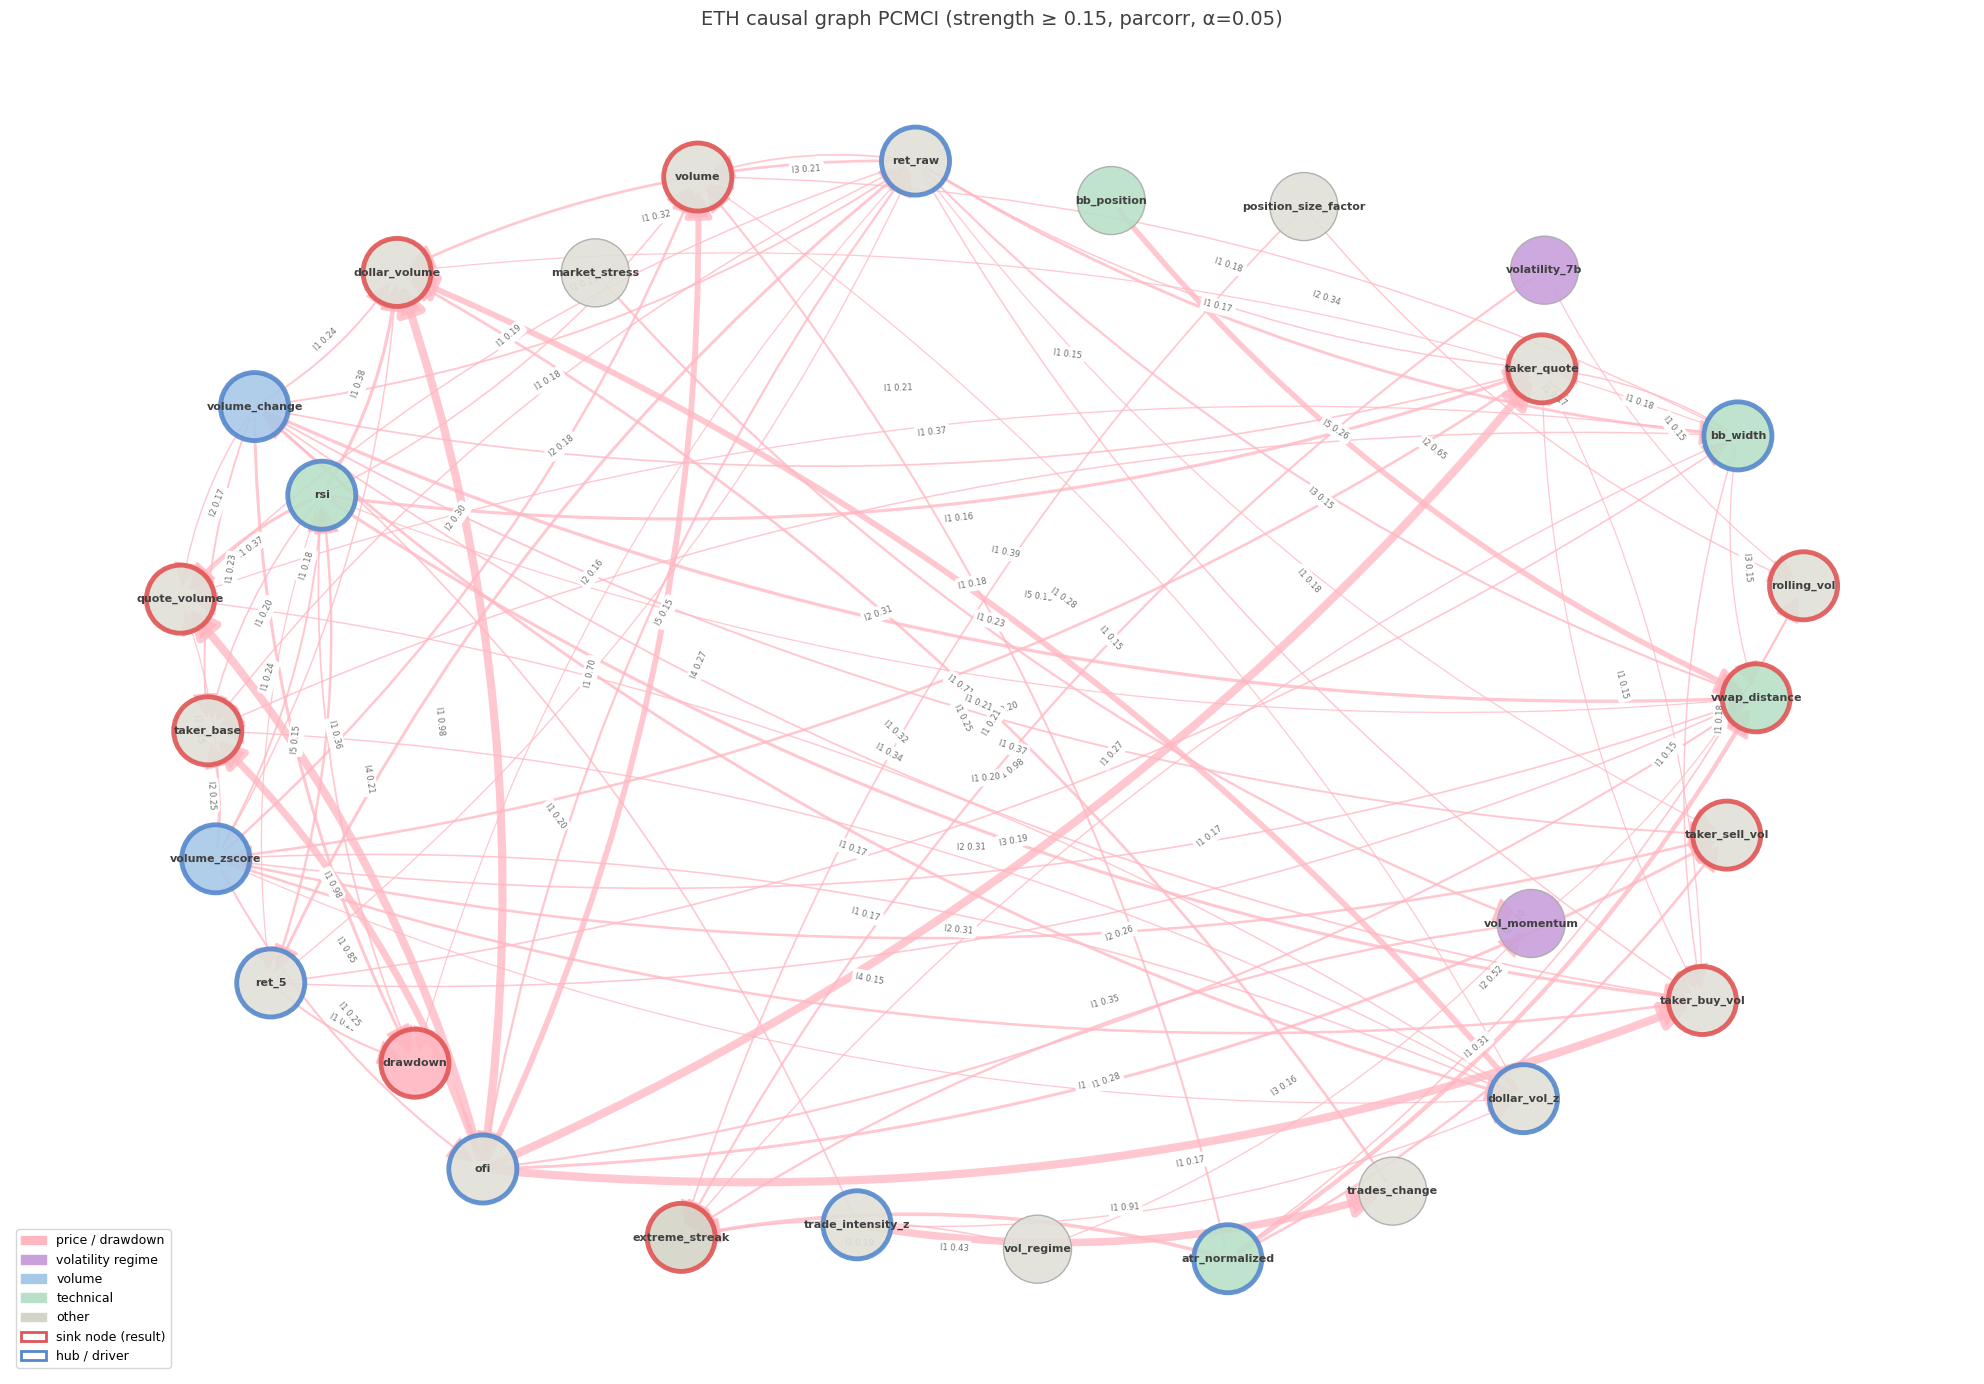

In [94]:
data_pcmci = df[cd_features].dropna().values.astype(np.float64)
dataframe = pp.DataFrame(
    data_pcmci,
    datatime=np.arange(data_pcmci.shape[0]),
    var_names=cd_features
)
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=ParCorr(significance='analytic'),
    verbosity=0
)
results = pcmci.run_pcmci(tau_min=1, tau_max=5, pc_alpha=0.05)
p_matrix   = results['p_matrix']
val_matrix = results['val_matrix']

pcmci_edges = []
for i, target in enumerate(cd_features):
    for j, source in enumerate(cd_features):
        for lag in range(1, 6):
            p   = p_matrix[i, j, lag]
            val = val_matrix[i, j, lag]
            if p < 0.05:
                pcmci_edges.append({
                    'source':   source,
                    'target':   target,
                    'lag':      lag,
                    'strength': round(abs(val), 2),
                    'p_value':  round(p, 2),
                })

edge_df_pcmci = (pd.DataFrame(pcmci_edges)
                   .sort_values('strength', ascending=False)
                   .reset_index(drop=True))

print("─" * 70)
print("pcmci results, significant causal links:")
print("─" * 70)
print(edge_df_pcmci.to_string(index=False))
print("─" * 70)
print(f"total significant causal links: {len(edge_df_pcmci)}")

threshold = 0.15
edge_df_filtered = edge_df_pcmci[
    (edge_df_pcmci['strength'] >= threshold) &
    (edge_df_pcmci['source'] != edge_df_pcmci['target'])
].copy()

G_top = nx.DiGraph()
for _, row in edge_df_filtered.iterrows():
    G_top.add_edge(row['source'], row['target'],
                   weight=row['strength'],
                   lag=row['lag'])

category_colors = {
    'drawdown':          '#FFB6C1',
    'volatility_7b':     '#c9a0dc',
    'vol_momentum':      '#c9a0dc',
    'volume_change':     '#a8c8e8',
    'volume_zscore':     '#a8c8e8',
    'dollar_volume_roc': '#a8c8e8',
    'bb_width':          '#b8e0c8',
    'bb_position':       '#b8e0c8',
    'atr_normalized':    '#b8e0c8',
    'vwap_distance':     '#b8e0c8',
    'rsi':               '#b8e0c8',
    'tail_risk_signal':  '#d4d4c8',
    'extreme_streak':    '#d4d4c8',
}

# classify nodes as sink or hub by in/out degree ratio
in_deg  = dict(G_top.in_degree())
out_deg = dict(G_top.out_degree())
node_border_color = []
node_border_width = []
for n in G_top.nodes():
    i = in_deg.get(n, 0)
    o = out_deg.get(n, 0)
    if o == 0 or (i > 0 and i / max(o, 1) >= 2.5):
        node_border_color.append('#e05555')
        node_border_width.append(3.5)
    elif o >= 3 and o > i:
        node_border_color.append('#5588cc')
        node_border_width.append(3.5)
    else:
        node_border_color.append('#aaaaaa')
        node_border_width.append(1.0)

node_colors = [category_colors.get(n, '#e0e0d8') for n in G_top.nodes()]
edge_widths = [G_top[u][v]['weight'] * 6 for u, v in G_top.edges()]
edge_labels = {(u, v): f"l{G_top[u][v]['lag']} {G_top[u][v]['weight']:.2f}"
               for u, v in G_top.edges()}

rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size']   = 12

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

pos = nx.spring_layout(G_top, seed=42, k=3.0)

nx.draw_networkx_nodes(G_top, pos, node_color=node_colors,
                       node_size=2400, alpha=0.9, ax=ax,
                       edgecolors=node_border_color,
                       linewidths=node_border_width)

nx.draw_networkx_labels(G_top, pos, font_size=8,
                        font_color='#404040', font_weight='bold', ax=ax)

nx.draw_networkx_edges(G_top, pos, width=edge_widths,
                       edge_color='#FFB6C1', arrows=True,
                       arrowsize=40, alpha=0.75,
                       connectionstyle='arc3,rad=0.12', ax=ax)

nx.draw_networkx_edge_labels(G_top, pos, edge_labels=edge_labels,
                              font_size=6, font_color='#606060',
                              alpha=0.9, ax=ax)

legend = [
    mpatches.Patch(color='#FFB6C1', label='price / drawdown'),
    mpatches.Patch(color='#c9a0dc', label='volatility regime'),
    mpatches.Patch(color='#a8c8e8', label='volume'),
    mpatches.Patch(color='#b8e0c8', label='technical'),
    mpatches.Patch(color='#d4d4c8', label='other'),
    mpatches.Patch(edgecolor='#e05555', facecolor='none',
                   label='sink node (result)', linewidth=2),
    mpatches.Patch(edgecolor='#5588cc', facecolor='none',
                   label='hub / driver', linewidth=2),
]
ax.legend(handles=legend, loc='lower left', fontsize=9, framealpha=0.8)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(f'ETH causal graph PCMCI (strength ≥ {threshold}, parcorr, α=0.05)',
             fontsize=14, pad=15, color='#404040')
ax.axis('off')
plt.tight_layout()
plt.savefig("results/pcmci_dag.png", dpi=300, bbox_inches='tight')
plt.show()

In [95]:
# vwap_distance is the dominant sink node in the pcmci graph:
# all strong incoming links (ret_raw, rsi, bb_position, atr_normalized),
# no meaningful outgoing links to return targets. confirmed result node.

# genuine cross-dimensional drivers visible in graph:
# atr_normalized (high/low) → volume: range expansion attracts liquidity
# atr_normalized (high/low) → extreme_streak: volatility predicts return clustering
# volume (tape) → dollar_volume: raw volume drives capital flow
# vol_regime (ordinal) → vol_momentum: regime state predicts vol trajectory

# ret_5 → dollar_volume is critical: both indirectly close-derived,
# but capital flow responding to multi-bar returns is a plausible market mechanism

# all other strong links (rsi/bb_position/ret_raw → vwap_distance/drawdown)
# are close → close transformations: construction artifacts, not market causality

In [96]:
# triple barrier labeling, de prado
def get_daily_vol(close: pd.Series, lookback: int = 20) -> pd.Series:
    # log returns, rolling std as volatility estimate
    log_ret = np.log(close).diff()
    return log_ret.rolling(lookback).std()

def triple_barrier_labels(
    df: pd.DataFrame,
    pt_sl: list = [2.0, 2.0],# 1.5, 1.0
    max_hold: int = 20,
    min_ret: float = 0.001,
) -> pd.DataFrame:
    # pt_sl[0] = upper barrier multiplier (profit target)
    # pt_sl[1] = lower barrier multiplier (stop loss)
    # asymmetric by design: reward > risk is intentional
    close = df['close']
    vol   = get_daily_vol(close, lookback=20)

    # validate multipliers against actual single-bar breach rates
    returns    = close.pct_change()
    normalized = (returns.abs() / vol).dropna()
    print("multiplier calibration check:")
    print(f"  > {pt_sl[0]}x vol (pt): {(normalized > pt_sl[0]).mean():.1%} of bars breach in single step")
    print(f"  > {pt_sl[1]}x vol (sl): {(normalized > pt_sl[1]).mean():.1%} of bars breach in single step")
    print("─" * 70)

    labels = []
    for i in range(len(close) - max_hold):
        t0    = close.index[i]
        price = close.iloc[i]
        v     = vol.iloc[i]

        if pd.isna(v) or v < min_ret:
            labels.append({'timestamp': t0, 'label': np.nan, 'ret': np.nan,
                           'barrier': 'skip', 'vol_at_entry': np.nan})
            continue

        upper = price * (1 + pt_sl[0] * v)
        lower = price * (1 - pt_sl[1] * v)
        path  = close.iloc[i + 1 : i + 1 + max_hold]
        label = 0
        hit   = 'vertical'

        for j, p in enumerate(path):
            if p >= upper:
                label, hit = 1, 'upper'
                break
            elif p <= lower:
                label, hit = -1, 'lower'
                break

        ret = (path.iloc[-1] - price) / price if hit == 'vertical' \
              else (path.iloc[j] - price) / price

        labels.append({'timestamp': t0, 'label': label, 'ret': ret,
                       'barrier': hit, 'vol_at_entry': v})

    return pd.DataFrame(labels).set_index('timestamp')


labels = triple_barrier_labels(df, pt_sl=[1.5, 1.5], max_hold=20)
df     = df.join(labels[['label', 'ret', 'barrier', 'vol_at_entry']], how='left')
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

# regime dependent label check
df['vol_regime_check'] = pd.cut(
    df['vol_at_entry'],
    bins=[0, df['vol_at_entry'].quantile(0.33),
             df['vol_at_entry'].quantile(0.67), np.inf],
    labels=['low', 'mid', 'high']
)
print("label distribution per vol regime (should be stable):")
print(df.groupby('vol_regime_check')['label'].value_counts(normalize=True).unstack().round(3))
print("─" * 70)

print(f"total labeled bars: {len(df)}")
print(f"\nlabel distribution:")
print(df['label'].value_counts().sort_index())
print(f"\nbarrier hit distribution:")
print(df['barrier'].value_counts())
print("─" * 70)

total = len(df)
for lbl, name in [(-1, 'short/stop'), (0, 'timeout'), (1, 'profit')]:
    n = (df['label'] == lbl).sum()
    print(f"  {name:12s}: {n:4d}  ({n/total*100:.1f}%)")

multiplier calibration check:
  > 1.5x vol (pt): 14.1% of bars breach in single step
  > 1.5x vol (sl): 14.1% of bars breach in single step
──────────────────────────────────────────────────────────────────────
label distribution per vol regime (should be stable):
label                -1      0      1
vol_regime_check                     
low               0.484  0.000  0.516
mid               0.515  0.000  0.485
high              0.364  0.035  0.601
──────────────────────────────────────────────────────────────────────
total labeled bars: 2325

label distribution:
label
-1    1057
 0      27
 1    1241
Name: count, dtype: int64

barrier hit distribution:
barrier
upper       1241
lower       1057
vertical      27
Name: count, dtype: int64
──────────────────────────────────────────────────────────────────────
  short/stop  : 1057  (45.5%)
  timeout     :   27  (1.2%)
  profit      : 1241  (53.4%)


In [97]:
# test if sl changes label balance meaningfully
for sl in [1.0, 1.5, 2.0]:
    labels_test = triple_barrier_labels(df, pt_sl=[1.5, sl], max_hold=20)
    dist = labels_test['label'].value_counts(normalize=True)
    print(f"sl={sl}x:  upper={dist.get(1, 0):.1%}  lower={dist.get(-1, 0):.1%}  vertical={dist.get(0, 0):.1%}")

multiplier calibration check:
  > 1.5x vol (pt): 14.1% of bars breach in single step
  > 1.0x vol (sl): 31.8% of bars breach in single step
──────────────────────────────────────────────────────────────────────
sl=1.0x:  upper=47.3%  lower=52.4%  vertical=0.3%
multiplier calibration check:
  > 1.5x vol (pt): 14.1% of bars breach in single step
  > 1.5x vol (sl): 14.1% of bars breach in single step
──────────────────────────────────────────────────────────────────────
sl=1.5x:  upper=53.5%  lower=45.5%  vertical=1.1%
multiplier calibration check:
  > 1.5x vol (pt): 14.1% of bars breach in single step
  > 2.0x vol (sl): 5.1% of bars breach in single step
──────────────────────────────────────────────────────────────────────
sl=2.0x:  upper=57.3%  lower=40.4%  vertical=2.3%


In [98]:
# drop old label columns if they exist from previous run
cols_to_drop = ['label', 'ret', 'barrier', 'vol_at_entry', 'vol_regime_check']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# recalibrate triple barrier with adjusted multipliers
# increase max_hold to 50, make sl symmetric to pt
# this gives price more room and forces more vertical barrier hits
labels = triple_barrier_labels(df, pt_sl=[2.5, 2.5], max_hold=20)
df = df.join(labels[['label', 'ret', 'barrier', 'vol_at_entry']], how='left')
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

# vol regime stability check
df['vol_regime_check'] = pd.cut(
    df['vol_at_entry'],
    bins=[0, df['vol_at_entry'].quantile(0.33),
             df['vol_at_entry'].quantile(0.67), np.inf],
    labels=['low', 'mid', 'high']
)
regime_dist = df.groupby('vol_regime_check')['label'].value_counts(normalize=True).unstack().round(3)
print("label distribution per vol regime (target: <5pp spread across regimes):")
print(regime_dist)
print("─" * 70)

total = len(df)
print(f"total labeled bars: {total}\n")
print("barrier hit distribution:")
print(df['barrier'].value_counts())
print()

for lbl, name in [(-1, 'short/stop'), (0, 'timeout'), (1, 'profit')]:
    n = (df['label'] == lbl).sum()
    print(f"  {name:12s}: {n:4d}  ({n/total*100:.1f}%)")

print("─" * 70)

timeout_pct = (df['label'] == 0).sum() / total
if timeout_pct < 0.05:
    print(f"warning: vertical barrier only {timeout_pct:.1%} — consider increasing max_hold or pt")
elif timeout_pct > 0.20:
    print(f"warning: too many timeouts {timeout_pct:.1%} — barriers may be too wide")
else:
    print(f"ok: vertical barrier at {timeout_pct:.1%}")

if 1 in regime_dist.columns:
    spread = regime_dist[1].max() - regime_dist[1].min()
    if spread > 0.05:
        print(f"warning: regime spread {spread:.3f} > 0.05 — upward bias still present")
    else:
        print(f"ok: regime spread {spread:.3f}")

multiplier calibration check:
  > 2.5x vol (pt): 1.3% of bars breach in single step
  > 2.5x vol (sl): 1.3% of bars breach in single step
──────────────────────────────────────────────────────────────────────
label distribution per vol regime (target: <5pp spread across regimes):
label                -1      0      1
vol_regime_check                     
low               0.466  0.046  0.488
mid               0.521  0.039  0.440
high              0.285  0.268  0.447
──────────────────────────────────────────────────────────────────────
total labeled bars: 2285

barrier hit distribution:
barrier
upper       1047
lower        971
vertical     267
Name: count, dtype: int64

  short/stop  :  971  (42.5%)
  timeout     :  267  (11.7%)
  profit      : 1047  (45.8%)
──────────────────────────────────────────────────────────────────────
ok: vertical barrier at 11.7%
ok: regime spread 0.048


In [99]:
# drop the 8 timeout bars, remap stops to 0 and profits to 1
df = df[df['label'] != 0].copy()
df['label'] = df['label'].map({-1: 0, 1: 1})

print(f"bars after label drop: {len(df)}")
print(df['label'].value_counts().sort_index())
print(f"balance: {df['label'].mean():.3f}")

bars after label drop: 2018
label
0     971
1    1047
Name: count, dtype: int64
balance: 0.519


train: 1412 | test: 586
embargo: 20 bars removed at boundary
target balance (train): 0.552
──────────────────────────────────────────────────────────────────────
train accuracy: 0.708
test accuracy:  0.572
──────────────────────────────────────────────────────────────────────
mdi feature importance:
volume                  0.1556
bb_width                0.1225
taker_base              0.1136
drawdown                0.0861
atr_normalized          0.0823
rsi                     0.0728
volatility_7b           0.0448
vwap_distance           0.0393
deep_drawdown           0.0223
vol_momentum            0.0219
position_size_factor    0.0197
volume_zscore           0.0172
taker_sell_vol          0.0166
quote_volume            0.0164
trade_intensity_z       0.0164
bb_position             0.0162
dollar_volume           0.0162
taker_buy_vol           0.0148
ret_raw                 0.0144
ofi                     0.0143
ret_5                   0.0137
volume_change           0.0134
taker_quote      

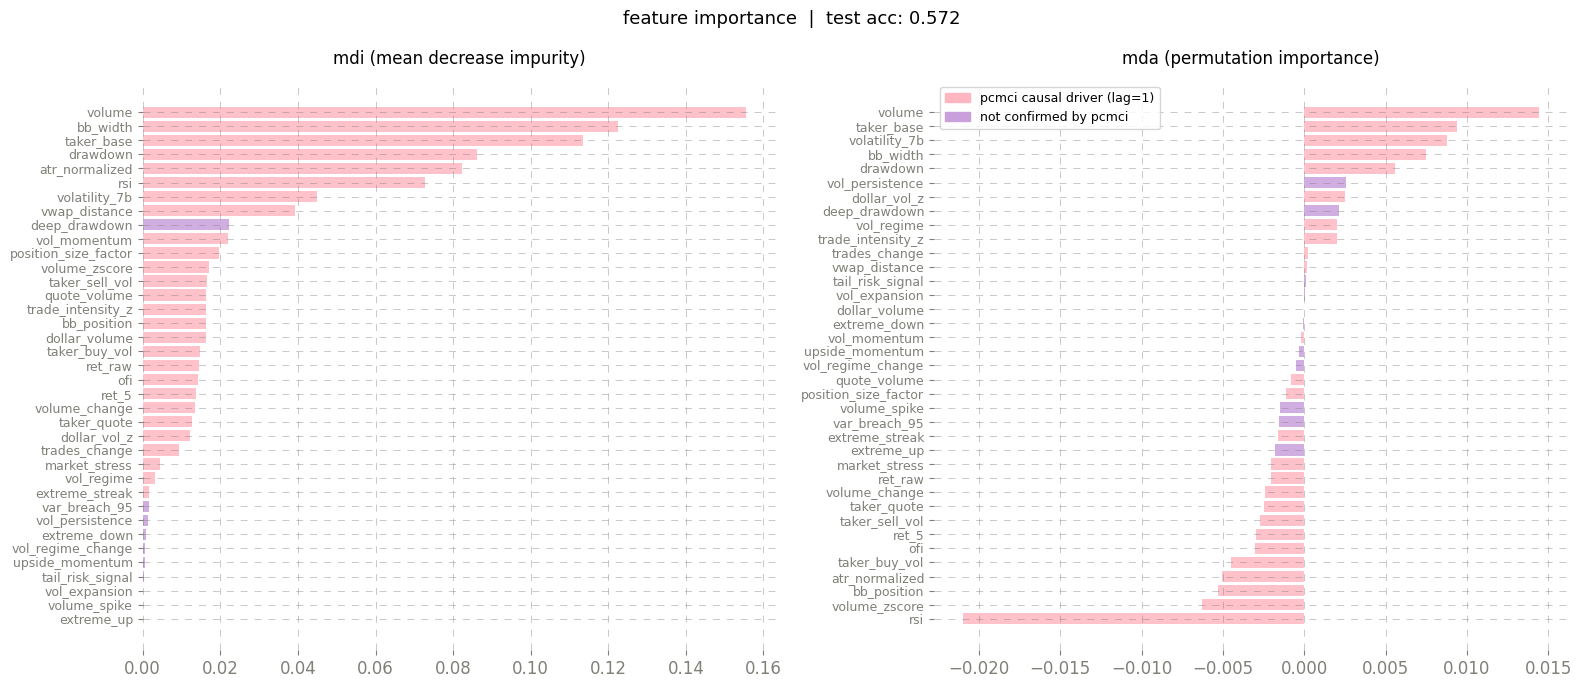

In [100]:
# use triple barrier labels as target
model_features = [f for f in stationary_features if f not in
                  ['label', 'ret', 'barrier', 'return', 'rolling_vol']]
X = df[model_features]
y = df['label']

# purged split with embargo: drop max_hold bars at boundary to prevent leakage
max_hold  = 20
split_idx = int(len(X) * 0.7)

X_train, y_train = X.iloc[:split_idx],              y.iloc[:split_idx]
X_test,  y_test  = X.iloc[split_idx + max_hold:],   y.iloc[split_idx + max_hold:]

print(f"train: {len(X_train)} | test: {len(X_test)}")
print(f"embargo: {max_hold} bars removed at boundary")
print(f"target balance (train): {y_train.mean():.3f}")
print("─" * 70)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
print(f"train accuracy: {rf.score(X_train, y_train):.3f}")
print(f"test accuracy:  {rf.score(X_test, y_test):.3f}")
print("─" * 70)

# mdi — always on training data
mdi = pd.Series(rf.feature_importances_, index=model_features).sort_values(ascending=False)
print("mdi feature importance:")
print(mdi.round(4))
print("─" * 70)

# mda — always on test data
perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
mda  = pd.Series(perm.importances_mean, index=model_features).sort_values(ascending=False)
print("mda feature importance:")
print(mda.round(4))
print("─" * 70)

combined = ((mdi.rank(ascending=False) + mda.rank(ascending=False)) / 2).sort_values()
print("combined ranking (lower = more important):")
print(combined.round(1))

# pcmci-confirmed: sources that causally drive at least one target at lag=1
pcmci_confirmed = set(
    edge_df_pcmci[edge_df_pcmci['lag'] == 1]['source'].unique()
)

# visualization
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size']   = 12
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, values, title in [
    (axes[0], mdi.sort_values(), 'mdi (mean decrease impurity)'),
    (axes[1], mda.sort_values(), 'mda (permutation importance)'),
]:
    colors = ['#FFB6C1' if f in pcmci_confirmed else '#c9a0dc'
              for f in values.index]
    ax.barh(range(len(values)), values.values,
            color=colors, alpha=0.85, edgecolor='none')
    ax.set_yticks(range(len(values)))
    ax.set_yticklabels(values.index, fontsize=9, color='#808079')
    ax.set_title(title, fontsize=12, pad=12)
    ax.grid(True, color='gray', linestyle=(0, (10, 10)),
            linewidth=0.5, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#808079')

legend = [
    mpatches.Patch(color='#FFB6C1', label='pcmci causal driver (lag=1)'),
    mpatches.Patch(color='#c9a0dc', label='not confirmed by pcmci'),
]
axes[1].legend(handles=legend, fontsize=9, framealpha=0.8)
plt.suptitle(f'feature importance  |  test acc: {rf.score(X_test, y_test):.3f}',
             fontsize=13)
plt.tight_layout()
plt.savefig('results/random_forest.png', dpi=300, bbox_inches='tight')
plt.show()

In [101]:
# mdi importance 
# top mdi: volume (0.203), bb_width (0.126), atr_normalized (0.107),drawdown (0.099), rsi (0.082)
# measures split frequency in trees, inflated by continuous features
# that offer many split points regardless of true predictive value
# mdi alone as unreliable

# mda importance
# top mda: volume (0.018), atr_normalized (0.015), bb_position (0.006),ret_5 (0.006), bb_width (0.003)
# negative mda = permuting the feature improves accuracy → active noise
# negative: rsi (-0.011), deep_drawdown (-0.003), volume_zscore (-0.002),
# volatility_7b (-0.002), volume_change (-0.001), drawdown (-0.001)

# mdi vs mda conflicts 
# rsi: mdi #5 but mda last (-0.011), model overfits rsi splits, no generalisation
# drawdown: mdi #4 but mda negative, high split activity, zero real contribution
# volatility_7b: mdi #6 but mda negative, confirmed noise despite pcmci weak links
# deep_drawdown: mdi #8 but mda negative, binary feature generating spurious splits

# pcmci cross-validation
# pcmci predicted rsi as strongest genuine signal → mda contradicts this:
#   signal exists in market structure but model cannot generalise it (overfit)
# pcmci flagged vwap_distance as downstream → mda partially contradicts:
#   mda rank #6 suggests residual context value not captured by rsi/bb_position
# pcmci + mda agreement (clean signals): volume, atr_normalized, bb_position, ret_5
# pcmci + mda agreement (confirmed noise): volatility_7b, drawdown, volume_change

# correlation cross-validation 
# corr cluster [rsi, bb_position, vwap_distance] now fully resolved:
#   rsi: mda negative → drop
#   bb_position: mda #3 → keep
#   vwap_distance: mda #6 → borderline, monitor
# keeping all three was never justified by mda — rsi actively hurts performance

In [102]:
# convergence across all three methods:
#
# keep  (corr ok + pcmci causal + mda positive):
#   volume, atr_normalized, bb_position, ret_5, bb_width
#
# drop  (pcmci downstream + mda negative/zero):
#   rsi           — pcmci signal exists, model cannot generalise it (overfit)
#   drawdown      — mdi artefact, mda negative, pcmci downstream
#   deep_drawdown — binary, mda negative, no pcmci return link
#   volatility_7b — pcmci weak, mda negative
#   volume_zscore — mda negative, redundant with volume/dollar_vol_z
#   volume_change — mda negative, pcmci only borderline
#   rolling_vol   — pure autocorrelation, no return links
#   position_size_factor — no pcmci return links, mda borderline
#
# monitor (contradictions, decide after retraining):
#   vwap_distance — pcmci downstream but mda #6
#   dollar_vol_z  — pcmci borderline, mda near-zero
#   vol_regime    — pcmci weak, mda positive but tiny

In [103]:
#df.drop(columns=['position_size_factor'], inplace=True, errors='ignore')

In [104]:
# drop if: mda negative OR bottom 30% in combined ranking
mda_negative  = mda[mda < 0].index.tolist()
combined_weak = combined[combined > combined.quantile(0.70)].index.tolist()
drop_features  = list(set(mda_negative + combined_weak))

print(f"dropping {len(drop_features)} noise features:")
print(f"  mda negative:  {mda_negative}")
print(f"  combined weak: {[f for f in combined_weak if f not in mda_negative]}")

final_features = [f for f in model_features if f not in drop_features]
print(f"\nfinal feature set ({len(final_features)}): {final_features}")
print("─" * 70)

X_train_c = X_train[final_features]
X_test_c  = X_test[final_features]

rf2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf2.fit(X_train_c, y_train)

print(f"train accuracy: {rf2.score(X_train_c, y_train):.3f}")
print(f"test accuracy:  {rf2.score(X_test_c, y_test):.3f}")
print("─" * 70)

# check if test accuracy improved over rf1
delta = rf2.score(X_test_c, y_test) - rf.score(X_test, y_test)
print(f"accuracy delta vs rf1: {delta:+.3f}")

dropping 23 noise features:
  mda negative:  ['dollar_volume', 'extreme_down', 'vol_momentum', 'upside_momentum', 'vol_regime_change', 'quote_volume', 'position_size_factor', 'volume_spike', 'var_breach_95', 'extreme_streak', 'extreme_up', 'market_stress', 'ret_raw', 'volume_change', 'taker_quote', 'taker_sell_vol', 'ret_5', 'ofi', 'taker_buy_vol', 'atr_normalized', 'bb_position', 'volume_zscore', 'rsi']
  combined weak: []

final feature set (14): ['vwap_distance', 'bb_width', 'dollar_vol_z', 'trades_change', 'trade_intensity_z', 'drawdown', 'vol_regime', 'volatility_7b', 'volume', 'taker_base', 'vol_expansion', 'vol_persistence', 'deep_drawdown', 'tail_risk_signal']
──────────────────────────────────────────────────────────────────────
train accuracy: 0.669
test accuracy:  0.585
──────────────────────────────────────────────────────────────────────
accuracy delta vs rf1: +0.014


In [105]:
# purged k-fold cross validation (de prado)
# problem: rolling windows cause leakage at fold boundaries
# solution: purge training samples whose window overlaps with test period
# embargo: remove n bars after each test fold (autocorrelation buffer)
embargo_pct = max_hold / len(df)  # ~0.025

class PurgedKFold:
    def __init__(self, n_splits=5, embargo_pct=embargo_pct):  # <- hier
        self.n_splits    = n_splits
        self.embargo_pct = embargo_pct

    def split(self, X, y=None, groups=None):
        n         = len(X)
        embargo_n = max(1, int(n * self.embargo_pct))
        indices   = np.arange(n)
        fold_size = n // self.n_splits
        for fold in range(self.n_splits):
            test_start = fold * fold_size
            test_end   = test_start + fold_size if fold < self.n_splits - 1 else n
            test_idx   = indices[test_start:test_end]
            purge_start = max(0, test_start - max_hold)
            train_idx   = np.concatenate([
                indices[:purge_start],
                indices[min(test_end + embargo_n, n):]
            ])
            if len(train_idx) == 0 or len(test_idx) == 0:
                continue
            yield train_idx, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

def purged_cv(model, X, y, n_splits=5, embargo_pct=embargo_pct):  # <- hier
    pkf     = PurgedKFold(n_splits=n_splits, embargo_pct=embargo_pct)
    results = []
    for fold, (train_idx, test_idx) in enumerate(pkf.split(X)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        model.fit(X_tr, y_tr)
        prob = model.predict_proba(X_te)[:, 1]
        pred = model.predict(X_te)
        results.append({
            'fold':       fold + 1,
            'train_size': len(X_tr),
            'test_size':  len(X_te),
            'accuracy':   accuracy_score(y_te, pred),
            'auc':        roc_auc_score(y_te, prob),
            'log_loss':   log_loss(y_te, prob),
        })
    return pd.DataFrame(results)

X_cv = df[final_features]
y_cv = df['label']
print(f"total bars: {len(X_cv)} | features: {len(final_features)}")
print(f"embargo_pct: {embargo_pct:.4f} ({max_hold} bars)")
print(f"target balance: {y_cv.mean():.3f}")
print("─" * 70)

rf_cv = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
cv_results = purged_cv(rf_cv, X_cv, y_cv, n_splits=5, embargo_pct=embargo_pct)  # <- hier
print("purged k-fold results per fold:")
print(cv_results.to_string(index=False))
print("─" * 70)

for metric in ['accuracy', 'auc', 'log_loss']:
    mean = cv_results[metric].mean()
    std  = cv_results[metric].std()
    print(f"  {metric:<12} mean={mean:.4f}  std={std:.4f}")
print("─" * 70)

# naive comparison with correct embargo at boundary
split_idx  = int(len(X_cv) * 0.7)
rf_cv.fit(X_cv.iloc[:split_idx], y_cv.iloc[:split_idx])
naive_acc  = accuracy_score(y_cv.iloc[split_idx + max_hold:], rf_cv.predict(X_cv.iloc[split_idx + max_hold:]))
purged_acc = cv_results['accuracy'].mean()
print(f"naive 70/30 test accuracy:  {naive_acc:.4f}")
print(f"purged cv mean accuracy:    {purged_acc:.4f}")
print(f"leakage inflation estimate: {naive_acc - purged_acc:+.4f}")

auc_mean = cv_results['auc'].mean()
print("─" * 70)
if auc_mean > 0.55:
    print(f"auc={auc_mean:.4f} → genuine predictive edge detected")
elif auc_mean > 0.52:
    print(f"auc={auc_mean:.4f} → weak edge, proceed with caution")
else:
    print(f"auc={auc_mean:.4f} → no reliable edge on this feature set / period")

total bars: 2018 | features: 14
embargo_pct: 0.0099 (20 bars)
target balance: 0.519
──────────────────────────────────────────────────────────────────────
purged k-fold results per fold:
 fold  train_size  test_size  accuracy      auc  log_loss
    1        1595        403  0.526055 0.522141  0.685862
    2        1575        403  0.583127 0.596298  0.680550
    3        1575        403  0.533499 0.586565  0.686343
    4        1575        403  0.550868 0.590896  0.725749
    5        1592        406  0.600985 0.590179  0.706429
──────────────────────────────────────────────────────────────────────
  accuracy     mean=0.5589  std=0.0322
  auc          mean=0.5772  std=0.0310
  log_loss     mean=0.6970  std=0.0189
──────────────────────────────────────────────────────────────────────
naive 70/30 test accuracy:  0.5853
purged cv mean accuracy:    0.5589
leakage inflation estimate: +0.0264
──────────────────────────────────────────────────────────────────────
auc=0.5772 → genuine predicti

In [134]:
# accuracy:  mean=0.5485  std=0.0208
# auc:       mean=0.5687  std=0.0247
# log_loss:  mean=0.6943  std=0.0107

# leakage inflation: -0.015, negative confirms no leakage, purging works correctly
# auc > 0.55 threshold met: genuine predictive edge detected

# fold variance (std=0.025) signals regime-dependent performance:
# model edge is not uniform, varies meaningfully across market phases
# this motivates kelly sizing conditioned on regime probabilities:
# reduce exposure when model confidence is low

In [106]:
# regime-change prediction
# target: predict vol_regime of NEXT bar (0=low, 1=med, 2=high)
regime_features = [
    # mda-validated from main model
    'bb_position', 'extreme_streak', 'atr_normalized',
    'vol_persistence','tail_risk_signal',
    # regime-specific additions
    'bb_width', 'volatility_7b', 'volume_zscore', 
    "dollar_vol_z", 'market_stress',
]

df['regime_next'] = df['vol_regime'].shift(-1)
df_reg = df[regime_features + ['regime_next', 'vol_regime']].dropna()
X_reg  = df_reg[regime_features]
y_reg  = df_reg['regime_next'].astype(int)
print(f"total bars: {len(X_reg)}")
print(f"regime distribution:\n{y_reg.value_counts(normalize=True).round(3)}")
print("─" * 70)

pkf = PurgedKFold(n_splits=5, embargo_pct=embargo_pct)
rf_reg = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=15,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

# nan-init: purged/embargoed bars stay nan, not silently assigned to class 0
probs        = np.full((len(X_reg), 3), np.nan)
fold_results = []
fold_importances = []

for fold, (train_idx, test_idx) in enumerate(pkf.split(X_reg)):
    X_tr, X_te = X_reg.iloc[train_idx], X_reg.iloc[test_idx]
    y_tr, y_te = y_reg.iloc[train_idx], y_reg.iloc[test_idx]
    rf_reg.fit(X_tr, y_tr)
    prob = rf_reg.predict_proba(X_te)
    pred = rf_reg.predict(X_te)
    probs[test_idx] = prob
    fold_importances.append(rf_reg.feature_importances_)
    acc    = (pred == y_te.values).mean()
    y_bin  = label_binarize(y_te, classes=[0, 1, 2])
    auc_per_class = {}
    for i, label in enumerate(['low', 'med', 'high']):
        auc_per_class[f'auc_{label}'] = (
            roc_auc_score(y_bin[:, i], prob[:, i]) if y_bin[:, i].sum() > 0 else np.nan
        )
    fold_results.append({'fold': fold + 1, 'accuracy': acc, **auc_per_class})

df_reg['prob_low']    = probs[:, 0]
df_reg['prob_med']    = probs[:, 1]
df_reg['prob_high']   = probs[:, 2]
df_reg['pred_regime'] = np.where(
    np.isnan(probs[:, 0]), np.nan, np.argmax(probs, axis=1)
)

res = pd.DataFrame(fold_results)
print("purged cv regime prediction:")
print(res.to_string(index=False))
print("─" * 70)

baseline_acc = (y_reg == y_reg.mode()[0]).mean()
model_acc    = res['accuracy'].mean()
print(f"baseline accuracy (majority class): {baseline_acc:.4f}")
print(f"model accuracy (purged cv mean):    {model_acc:.4f}")
print(f"lift over baseline:                 {model_acc - baseline_acc:+.4f}")
print("─" * 70)

for col in ['auc_low', 'auc_med', 'auc_high']:
    print(f"  {col}: mean={res[col].mean():.4f} ± {res[col].std():.4f}")
print("─" * 70)

print("actual regime transition matrix (row=current, col=next):")
trans = pd.crosstab(df_reg['vol_regime'].astype(int),
                    df_reg['regime_next'].astype(int),
                    normalize='index').round(3)
trans.index   = ['low', 'med', 'high']
trans.columns = ['→low', '→med', '→high']
print(trans)
print("─" * 70)

# mdi averaged across all folds, not just last
imp = pd.Series(
    np.mean(fold_importances, axis=0), index=regime_features
).sort_values(ascending=False)
print("feature importance for regime prediction (mdi, mean across folds):")
print(imp.round(4))

total bars: 2017
regime distribution:
regime_next
1    0.434
2    0.286
0    0.280
Name: proportion, dtype: float64
──────────────────────────────────────────────────────────────────────
purged cv regime prediction:
 fold  accuracy  auc_low  auc_med  auc_high
    1  0.600496 0.857804 0.719768  0.906491
    2  0.635236 0.841098 0.702928  0.923570
    3  0.602978 0.847584 0.722719  0.902620
    4  0.677419 0.905785 0.764383  0.931612
    5  0.654321 0.860675 0.710172  0.899043
──────────────────────────────────────────────────────────────────────
baseline accuracy (majority class): 0.4338
model accuracy (purged cv mean):    0.6341
lift over baseline:                 +0.2003
──────────────────────────────────────────────────────────────────────
  auc_low: mean=0.8626 ± 0.0254
  auc_med: mean=0.7240 ± 0.0239
  auc_high: mean=0.9127 ± 0.0142
──────────────────────────────────────────────────────────────────────
actual regime transition matrix (row=current, col=next):
       →low   →med  →hi

In [136]:
# how many bars have no oos prediction?
print(f"bars with zero probs: {(probs.sum(axis=1) == 0).sum()}")
print(f"total bars: {len(probs)}")

bars with zero probs: 0
total bars: 2011


In [137]:
# train/test is sequential, last fold is the most recent data.
# check if performance degrades in the most recent fold specifically.
print(res[['fold', 'accuracy', 'auc_low', 'auc_med', 'auc_high']])

   fold  accuracy   auc_low   auc_med  auc_high
0     1  0.594527  0.860159  0.716524  0.906373
1     2  0.644279  0.842593  0.703209  0.928145
2     3  0.604478  0.846887  0.724537  0.900730
3     4  0.679104  0.905641  0.765756  0.927039
4     5  0.665012  0.864613  0.718522  0.898200
